In [1]:
from gradio_client import Client   # for api use

import ast                         # for text to list conversion (make data useful)
import pandas as pd                # for easy data use; you can use polars or whatever you like

# start 8:14pm

# Accessing the API

Accessing the API is simple. You pass your key to the client, and then you will see a message the API has loaded.

In [2]:
token = '../api_creds/vi_key_1.csv'

# load my key
df = pd.read_csv(token) # easy and lazy lol; using pandas anyway ;p
api_key = df['key'][0]  # easy and lazy lol; using pandas anyway ;p

# connect to api
client = Client("verdantintel/verdanteye", token=api_key)

Loaded as API: https://verdantintel-verdanteye.hf.space


# Helper Function

In [3]:
def ask_api(client, question):

    answer = client.predict(question=question, api_name="/predict")
    
    answer = ast.literal_eval(answer)

    return answer

# Searching for Data

In [4]:
question = 'what has been seen in the last six hours?'

answer = ask_api(client, question)
len(answer)

1389

In [5]:
answer[0]

{'claim': 'A UHP trooper has resigned after being charged with lewdness involving a teen.',
 'url': 'https://ksl.com/article/51467344/uhp-trooper-resigns-after-being-charged-with-lewdness-involving-teen#comment_1',
 'domain': 'ksl.com',
 'url_domain': 'ksl.com',
 'date_added': '2026-03-18 03:13:03'}

In [9]:
df = pd.DataFrame(answer)
df['date_added'] = pd.to_datetime(df['date_added'], utc=True)
df['date_added'] = df['date_added'].dt.tz_convert('America/Los_Angeles') # put into my timezone
df.sort_values('date_added', ascending=False, inplace=True)
df.head()

,claim,url,domain,url_domain,date_added
0,A UHP trooper has resigned after being charged...,https://ksl.com/article/51467344/uhp-trooper-r...,ksl.com,ksl.com,2026-03-17 20:13:03-07:00
1,Event for Jerry's Middle Finger featuring 2 sets,https://www.tixr.com/groups/hiddenhall/events/...,nectarlounge.com/events/calendar,tixr.com,2026-03-17 20:11:39-07:00
2,Event featuring Com Truise with Manatee Commune,https://www.tixr.com/groups/nectarlounge/event...,nectarlounge.com/events/calendar,tixr.com,2026-03-17 20:11:39-07:00
3,Event featuring GZA with Phunky Nomads and DJ ...,https://www.tixr.com/groups/nectarlounge/event...,nectarlounge.com/events/calendar,tixr.com,2026-03-17 20:11:39-07:00
4,15th Anniversary show for Nite Wave,https://www.tixr.com/groups/nectarlounge/event...,nectarlounge.com/events/calendar,tixr.com,2026-03-17 20:11:39-07:00


In [10]:
df.tail() # six hours

,claim,url,domain,url_domain,date_added
1384,Rabbi in Schenectady faced antisemitic threats...,https://wnyt.com/top-stories/schenectady-rabbi...,wnyt.com,wnyt.com,2026-03-17 14:15:51-07:00
1385,Gas leak in Vancouver leads to evacuation of 2...,https://kptv.com/2026/03/17/crews-respond-gas-...,kptv.com,kptv.com,2026-03-17 14:15:46-07:00
1386,Event details for Anna Maria Villa at Vetro Re...,https://www.amventertainment.com/friday-march-...,amventertainment.com,amventertainment.com,2026-03-17 14:15:36-07:00
1387,Announcement or promotion related to an event ...,https://rpba.org/2026/03/spiral-into-spring-2026/,rpba.org/events,rpba.org,2026-03-17 14:15:25-07:00
1388,Lawyers attempt to dismiss evidence of a murde...,https://www.foxnews.com/us/mangiones-lawyers-m...,foxnews.com,foxnews.com,2026-03-17 14:15:18-07:00


In [11]:
df.shape

(1389, 5)

# Clustering

Clustering is useful for seeing the kinds of things that are happening. If you want to do trend analysis, start with clustering or filtering. You will want to have clustering in your skillset/toolset. Here is my graph+nlp approach, my own approach.

Tweak the similarity threshold to get what you want. 1 is exact match. 0 is no match. 0.5-0.8 is typically pretty sweet, but it depends on what you are doing. Sometimes lower is useful. Sometimes very high is useful. Be thoughtful about what you are trying to do and it will make sense. Ask me if you would like to learn more.

In [12]:
import pandas as pd
import numpy as np
import networkx as nx
import community as community_louvain

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [13]:
def cluster_text(texts, similarity_threshold=0.5):

    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        lowercase=True,
        sublinear_tf=True
    )

    tfidf_matrix = vectorizer.fit_transform(texts)

    similarity_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)
    adj_matrix = (similarity_matrix > similarity_threshold).astype(int)

    G = nx.from_numpy_array(adj_matrix)
    partition = community_louvain.best_partition(G, resolution=0.5, random_state=1337) 

    return list(partition.values())

In [14]:
df.head()

,claim,url,domain,url_domain,date_added
0,A UHP trooper has resigned after being charged...,https://ksl.com/article/51467344/uhp-trooper-r...,ksl.com,ksl.com,2026-03-17 20:13:03-07:00
1,Event for Jerry's Middle Finger featuring 2 sets,https://www.tixr.com/groups/hiddenhall/events/...,nectarlounge.com/events/calendar,tixr.com,2026-03-17 20:11:39-07:00
2,Event featuring Com Truise with Manatee Commune,https://www.tixr.com/groups/nectarlounge/event...,nectarlounge.com/events/calendar,tixr.com,2026-03-17 20:11:39-07:00
3,Event featuring GZA with Phunky Nomads and DJ ...,https://www.tixr.com/groups/nectarlounge/event...,nectarlounge.com/events/calendar,tixr.com,2026-03-17 20:11:39-07:00
4,15th Anniversary show for Nite Wave,https://www.tixr.com/groups/nectarlounge/event...,nectarlounge.com/events/calendar,tixr.com,2026-03-17 20:11:39-07:00


In [15]:
df['cluster'] = cluster_text(df['claim'], similarity_threshold=0.4) # reducing to capture broader topics
df.head()

,claim,url,domain,url_domain,date_added,cluster
0,A UHP trooper has resigned after being charged...,https://ksl.com/article/51467344/uhp-trooper-r...,ksl.com,ksl.com,2026-03-17 20:13:03-07:00,0
1,Event for Jerry's Middle Finger featuring 2 sets,https://www.tixr.com/groups/hiddenhall/events/...,nectarlounge.com/events/calendar,tixr.com,2026-03-17 20:11:39-07:00,1
2,Event featuring Com Truise with Manatee Commune,https://www.tixr.com/groups/nectarlounge/event...,nectarlounge.com/events/calendar,tixr.com,2026-03-17 20:11:39-07:00,2
3,Event featuring GZA with Phunky Nomads and DJ ...,https://www.tixr.com/groups/nectarlounge/event...,nectarlounge.com/events/calendar,tixr.com,2026-03-17 20:11:39-07:00,3
4,15th Anniversary show for Nite Wave,https://www.tixr.com/groups/nectarlounge/event...,nectarlounge.com/events/calendar,tixr.com,2026-03-17 20:11:39-07:00,4


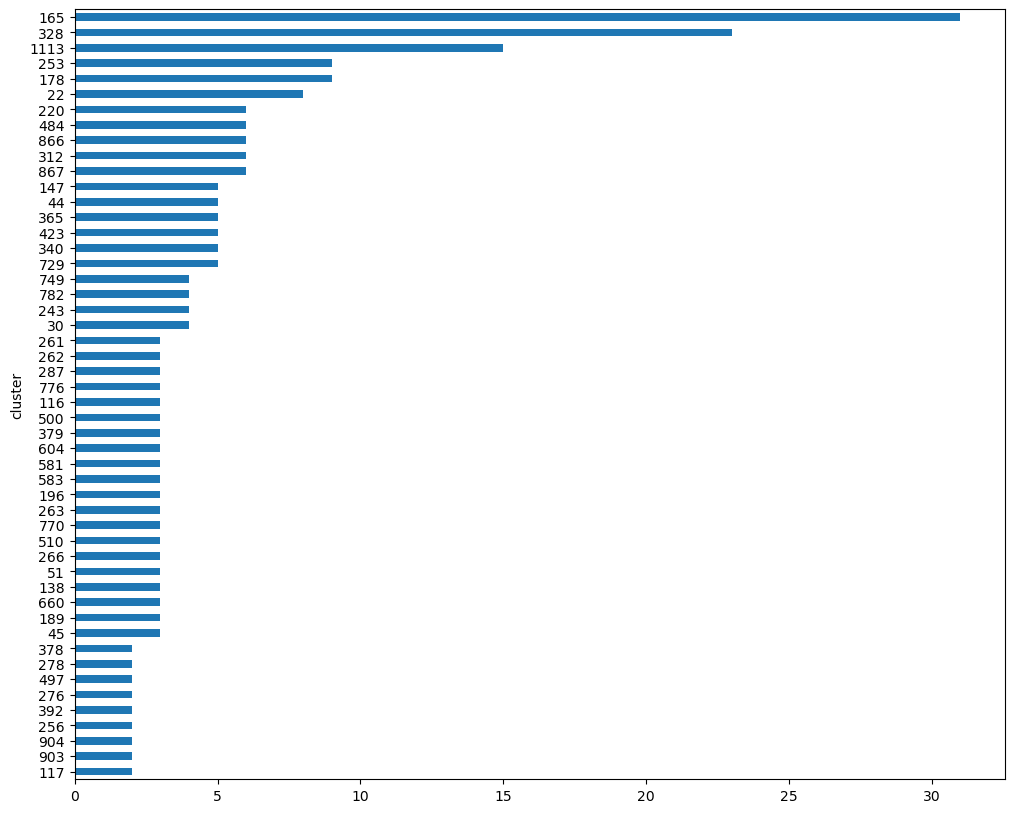

In [16]:
df['cluster'].value_counts()[0:50].plot.barh(figsize=(12,10)).invert_yaxis()

In [17]:
top_clusters = df['cluster'].value_counts().index.values
top_clusters

array([ 165,  328, 1113, ...,  412,  413,  554], dtype=int64)

In [20]:
for cluster in top_clusters:
    
    print('cluster: {}'.format(cluster))
    
    cluster_data = df[df['cluster']==cluster].head(20)['claim'].values
    print(cluster_data)
    
    print()

cluster: 165
['News article about a specific topic'
 'Post related to a topic of interest on Tumblr'
 'News article related to a specific topic or event'
 'News article related to an event or topic in Madrid'
 'Another news article related to Madrid'
 'A news article discussing a specific topic.'
 'A news article discussing a specific topic.'
 'A news article discussing a specific topic.' 'News article'
 'News article' 'News article or post' 'News article or post'
 'News article or post' 'News article or post'
 'A post related to a specific topic or event on Tumblr.'
 'Local crime and court news article.'
 'Local crime and court news article.'
 'News article related to a specific topic or event.'
 'News article related to a specific topic or event.'
 'News article related to a specific topic or event.']

cluster: 328
['An event is scheduled at the Denver library.'
 'An event is scheduled at the Classic Center.'
 'Details for an event happening at the Classic Center are provided.'
 'An 

['Luke Combs prioritizes family over industry events despite facing award consequences.']

cluster: 676
['Discussion about the targeting of lawyers and judges']

cluster: 677
['Report on the murder of an 11-year-old girl in Kanpur']

cluster: 678
['Event announcement for a Rosh Chodesh Niggun Circle']

cluster: 679
['Event announcement for an 80s improv challenge']

cluster: 680
["Information about the venue 'Young Ethel's'"]

cluster: 681
['Man pleads guilty in connection with the death of a William & Mary running back']

cluster: 646
['A court refused to discharge a mayor from a 2016 assault case.']

cluster: 644
['Today host Dylan Dreyer has filed for divorce from Brian Fichera after eight months of separation.']

cluster: 683
['A bus driver from Bay Shore School District has been charged with child sex assault.']

cluster: 625
['An event featuring the band Cake will take place in Sacramento, California, on March 21, 2026.']

cluster: 611
['A report showcasing Quincy’s new public sa

['Music Tower at Rye Playland Park was damaged by high winds.']

cluster: 1088
['A new jail in Penobscot County is costing 84 million dollars.']

cluster: 1073
['Disciplinary actions in Forsyth County K-12 schools increased despite lower enrollment.']

cluster: 1074
['Local support for unpaid TSA workers.']

cluster: 1075
['Striking nurses and caseworkers protesting in Lansing.']

cluster: 1076
['Brits racing to get meningitis jabs due to deadly outbreak.']

cluster: 1077
['Shooting near VA clinic in Jasper, Georgia under investigation.']

cluster: 1078
["The Riverside County Sheriff's Office is probing alleged irregularities in elections."]

cluster: 1079
["The Vanderburgh County Sheriff warns against drinking and driving on St. Patrick's Day."]

cluster: 1080
['Strong storms are causing significant damage in the Charlotte area, leading to increased work for roofers.']

cluster: 1081
['An Iredell County student was arrested after a lockdown connected to a senior assassin game.']

clus

['The family of a crash victim is suing Tesla, claiming design flaws in the Cybertruck.']

cluster: 294
['A judge has dismissed a religious discrimination lawsuit filed by PeaceHealth workers regarding the COVID vaccine.']

cluster: 295
['Officials are urging caution due to a heat wave in Southern California that is causing temperatures to soar.']

cluster: 296
['A brawl in Daytona Beach has escalated into gunfire.']

cluster: 297
["Megyn Kelly explains her reasons for not allowing her children's faces to be shown on a segment."]

cluster: 298
["A suspect in a woman's murder was granted bond, which was then revoked, and is now seeking bond again."]

cluster: 299
['A performance by Angie Louise and The Sirens of Swing as part of the Seattle Cabaret Festival 2026 on May 16.']

cluster: 300
['An event featuring Jacob Jonas The Company in Santa Monica scheduled for March 19, 2026.']

cluster: 301
['An event featuring Nour Khodr in Los Angeles scheduled for March 19, 2026.']

cluster: 302
[

['A North Carolina worker is facing deportation due to an incorrect turn that led into Fort Bragg.']

cluster: 573
['Event for queer individuals interested in martial arts.']

cluster: 574
['Recovery support event for queer individuals through NA.']

cluster: 575
['Tarot reading event hosted by Altaru Tarot.']

cluster: 576
['An ailing immigrant at risk of deportation is pleading to spend his last days with his daughter.']

cluster: 577
['Accusations are shaking the legacy of Cesar Chavez, leading to the cancellation of marches and events due to abuse allegations.']

cluster: 578
['Event announcement for a performance by Babyfxce E at the Cambridge Room in House of Blues, Dallas.']

cluster: 579
['An object found by a man at a Portland MAX station was not an explosive device.']

cluster: 582
['A Canadian drag queen theater announces a star-studded fundraiser for Palestine.']

cluster: 584
['Salem residents are encouraged to review proposed FEMA flood maps to avoid unexpected costs.']



In [19]:
# end 8:15pm